Campaña de Marketing Bancario

Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import os


In [30]:

df.to_csv('./data/raw/bank-marketing-campaign-data.csv', index=False)


Paso 1: Carga del conjunto de datos

In [11]:
url= "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
df = pd.read_csv(url)
df.head(5)

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


Exploracion inicial 

In [12]:

print(df.shape)


(41188, 1)


In [13]:
print(df.dtypes)


age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"    str
dtype: object


In [14]:
print(df.isnull().sum())


age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"    0
dtype: int64


In [15]:
print(df.describe())


       age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"
count                                               41188                                                                                                                                                                          
unique                                              41176                                                                                                                                                                          
top     39;"blue-collar";"married";"basic.6y";"no";"no...                                                                                                                                                                          
freq                                                    2                               

In [16]:
print(df.columns.tolist())

['age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"']


In [17]:
df = pd.read_csv(url, sep=';')
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [18]:
print(df['y'].value_counts())

y
no     36548
yes     4640
Name: count, dtype: int64


Los datos nos dicen que de 41,188 clientes contactados en la campaña:

36,548 no contratataron el depósito

4,640  Si contrataron el deposito

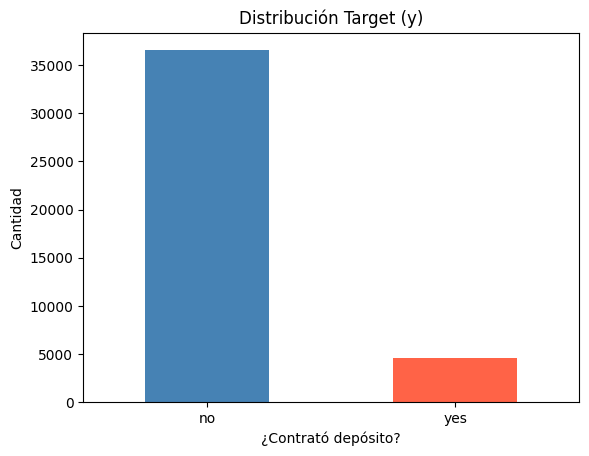

In [19]:
df['y'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Distribución Target (y)')
plt.xlabel('¿Contrató depósito?')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

El grafico nos muestra que tan desbalanceado estan las clases. Mostrando una barra azul cercano a 8 veces mas grande que la barra roja.

Eliminamos columnas inecesarias 

In [20]:
df = df.drop(columns=['duration'])

In [ ]:
#Encoding de variables categóricas 
df_model = df.copy()

# Columnas categóricas
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categóricas:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


/tmp/ipykernel_1202/916302067.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [23]:
# Spliting train / test 
X = df_model.drop(columns=['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (32950, 19) | Test: (8238, 19)


Accuracy: 0.9013109978150037

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.72      0.20      0.31       928

    accuracy                           0.90      8238
   macro avg       0.82      0.60      0.63      8238
weighted avg       0.89      0.90      0.88      8238



/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


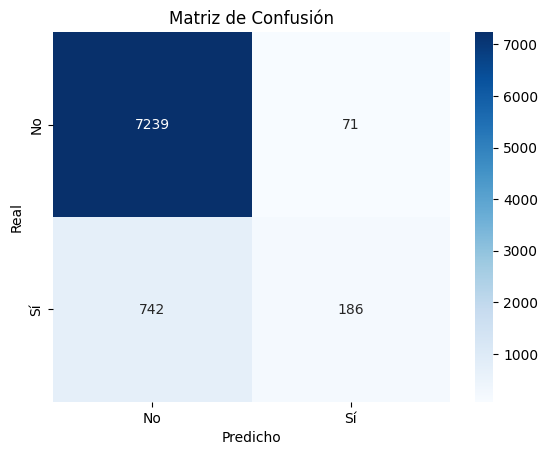

In [24]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Sí'], yticklabels=['No','Sí'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

 Resultados del Modelo Base (sin optimizar)

 Accuracy: 90% → Parece alto, pero es engañoso debido al desbalance de clases.
 El modelo aprendió a predecir "No" casi siempre, lo cual no es útil para el banco.

 Matriz de Confusión:
- 7239 clientes que NO contrataron → correctamente predichos (True Negative) 
- 71   clientes que NO contrataron → predichos como Sí (False Positive) 
- 742  clientes que SÍ contrataron → predichos como No (False Negative) 
- 186  clientes que SÍ contrataron → correctamente predichos (True Positive) 

 Conclusión: El modelo ignora 742/928 de los clientes interesados.
 el banco  está perdiendo oportunidades de venta reales.
 Necesitamos optimizar con class_weight='balanced' para mejorar el recall de la clase 1.

In [ ]:
# Pipeline con escalado + regresión logística
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Grid de hiperparámetros
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__solver': ['lbfgs', 'liblinear'],
    'clf__class_weight': [None, 'balanced']  
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5,
                           scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor F1 en CV:", grid_search.best_score_.round(4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__solver': 'liblinear'}
Mejor F1 en CV: 0.4278


Accuracy optimizado: 0.8130614226754066

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89      7310
           1       0.33      0.65      0.44       928

    accuracy                           0.81      8238
   macro avg       0.64      0.74      0.66      8238
weighted avg       0.88      0.81      0.84      8238



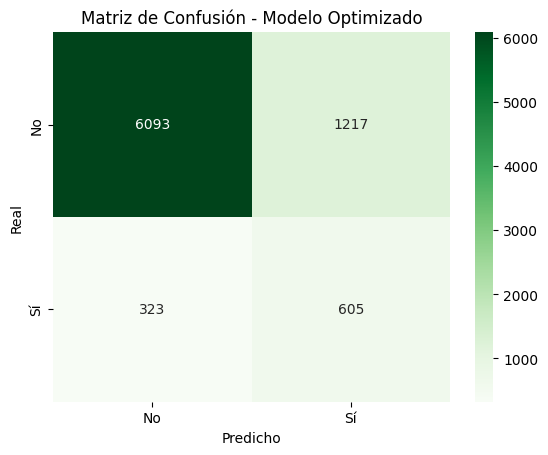

In [27]:
# Evaluar el modelo optimizado
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)

print("Accuracy optimizado:", accuracy_score(y_test, y_pred_opt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_opt))

cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No','Sí'], yticklabels=['No','Sí'])
plt.title('Matriz de Confusión - Modelo Optimizado')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

¿Qué mejoró?
 El modelo optimizado detecta ahora 605 clientes interesados vs solo 186 del modelo base.
 El recall de la clase "Sí" pasó de 20% a 65%, lo que significa que 
identificamos 3x más clientes potenciales.
Aunque el accuracy bajó del 90% al 81%, esto es esperado y deseable:
el modelo dejó de "hacer trampa" prediciendo siempre "No".

Trade-off aceptado
 Aumentaron los False Positives (71 → 1217): el banco contactará 
  a más clientes que no contratarán, pero **ese costo es menor** 
  que perder clientes reales interesados.

Conclusión
Para el banco, el modelo optimizado es claramente superior en 
términos de negocio: maximiza la detección de clientes con intención 
de contratar, que es exactamente el objetivo de la campaña.